# EDA: Transfers and Ratings
This notebook profiles the `transfers` and `ratings` datasets: datatypes, missing values, distributions, correlations, and some feature engineering for `position` and `league` when relevant.

In [1]:
# Imports
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
from pathlib import Path
sns.set(style="whitegrid")
pd.options.display.max_columns = 200
pd.options.display.width = 160

In [2]:
# Locate zip files in data/ and list their contents
data_dir = Path('..') / 'data'  # notebook is in notebooks/ so ../data
for p in data_dir.glob('*.zip'):
    print('ZIP:', p.name)
    with zipfile.ZipFile(p) as z:
        print('  contains ->', z.namelist())

ZIP: ratings.zip
  contains -> ['players_15.csv', 'players_16.csv', 'players_17.csv', 'players_18.csv', 'players_19.csv', 'players_20.csv', 'teams_and_leagues.csv']
ZIP: transfers.zip
  contains -> ['top250-00-19.csv']


In [3]:
# Adjust filenames below if the zip contains different internal names
transfers_zip = data_dir / 'transfers.zip'
ratings_zip = data_dir / 'ratings.zip'
# Pick first file inside each zip by default
with zipfile.ZipFile(transfers_zip) as z:
    transfers_name = z.namelist()[0]
with zipfile.ZipFile(ratings_zip) as z:
    ratings_name = z.namelist()[0]
print('using', transfers_name, 'and', ratings_name)
# Read specific files from the zip archives
with zipfile.ZipFile(transfers_zip) as z:
    with z.open(transfers_name) as f:
        transfers = pd.read_csv(f)
with zipfile.ZipFile(ratings_zip) as z:
    # ratings zip may contain multiple season files; we start with the first
    with z.open(ratings_name) as f:
        ratings = pd.read_csv(f)
print('transfers', transfers.shape)
print('ratings', ratings.shape)

using top250-00-19.csv and players_15.csv


transfers (4700, 10)
ratings (15465, 104)


## Helper: column profiling function
This helper prints datatype, missingness and overview statistics, and creates distribution plots appropriate to the column type.

In [4]:
def profile_column(df, col, figsize=(6,3)):
    s = df[col]
    dtype = s.dtype
    missing = s.isna().sum()
    pct_missing = 100 * missing / len(df)
    nunique = s.nunique(dropna=True)
    print(f'Column: {col}')
    print(' - dtype:', dtype)
    print(f' - missing: {missing} ({pct_missing:.2f}%)')
    print(' - unique (non-null):', nunique)
    if pd.api.types.is_numeric_dtype(s):
        print(s.describe())
        fig, ax = plt.subplots(1,2, figsize=(12,3))
        sns.histplot(s.dropna(), ax=ax[0], kde=True)
        sns.boxplot(x=s.dropna(), ax=ax[1])
        plt.suptitle(col)
        plt.show()
    else:
        # Categorical / object
        top = s.value_counts(dropna=False).head(20)
        display(top)
        plt.figure(figsize=figsize)
        sns.barplot(x=top.values, y=top.index)
        plt.title(col)
        plt.show()

## Profile: transfers dataset (all features)
We'll iterate every column and show basic stats and distributions.

In [5]:
# Quick overview
transfers.head()

,Name,Position,Age,Team_from,League_from,Team_to,League_to,Season,Market_value,Transfer_fee
0,Luís Figo,Right Winger,27,FC Barcelona,LaLiga,Real Madrid,LaLiga,2000-2001,NaN,60000000
1,Hernán Crespo,Centre-Forward,25,Parma,Serie A,Lazio,Serie A,2000-2001,NaN,56810000
2,Marc Overmars,Left Winger,27,Arsenal,Premier League,FC Barcelona,LaLiga,2000-2001,NaN,40000000
3,Gabriel Batistuta,Centre-Forward,31,Fiorentina,Serie A,AS Roma,Serie A,2000-2001,NaN,36150000
4,Nicolas Anelka,Centre-Forward,21,Real Madrid,LaLiga,Paris SG,Ligue 1,2000-2001,NaN,34500000


In [6]:
# Data types and missingness table for transfers
transfers_info = pd.DataFrame({
    'dtype': transfers.dtypes.astype(str),
    'n_missing': transfers.isna().sum(),
    'pct_missing': 100 * transfers.isna().mean(),
    'n_unique': transfers.nunique(dropna=True)
})
transfers_info.sort_values('pct_missing', ascending=False)

,dtype,n_missing,pct_missing,n_unique
Market_value,float64,1260,26.808511,180
Name,object,0,0.000000,3104
Position,object,0,0.000000,17
Age,int64,0,0.000000,22
League_from,object,0,0.000000,118
Team_from,object,0,0.000000,570
Team_to,object,0,0.000000,325
League_to,object,0,0.000000,65
Season,object,0,0.000000,19
Transfer_fee,int64,0,0.000000,507


Column: Name
 - dtype: object
 - missing: 0 (0.00%)
 - unique (non-null): 3104


Name
Alex                  8
Fernando              7
Peter Crouch          7
Craig Bellamy         6
Paulinho              6
Zlatan Ibrahimovic    6
Adriano               6
Sokratis              6
Éder                  6
Alberto Gilardino     6
Émerson               6
Carlos Tévez          6
Robbie Keane          6
Danilo                5
Mateja Kezman         5
Roberto               5
Ciro Immobile         5
Thiago Neves          5
Scott Parker          5
Giuliano              5
Name: count, dtype: int64

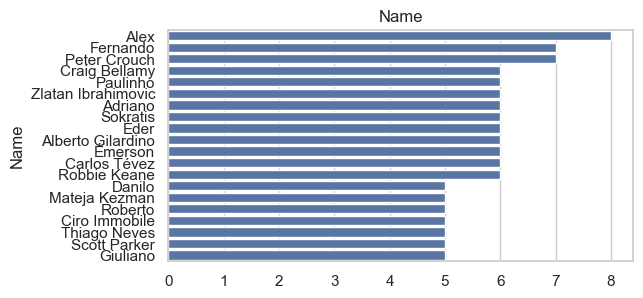


---

Column: Position
 - dtype: object
 - missing: 0 (0.00%)
 - unique (non-null): 17


Position
Centre-Forward        1218
Centre-Back            714
Central Midfield       487
Attacking Midfield     426
Defensive Midfield     411
Right Winger           305
Left Winger            267
Left-Back              225
Right-Back             181
Goalkeeper             180
Second Striker         130
Left Midfield           87
Right Midfield          63
Forward                  3
Sweeper                  1
Defender                 1
Midfielder               1
Name: count, dtype: int64

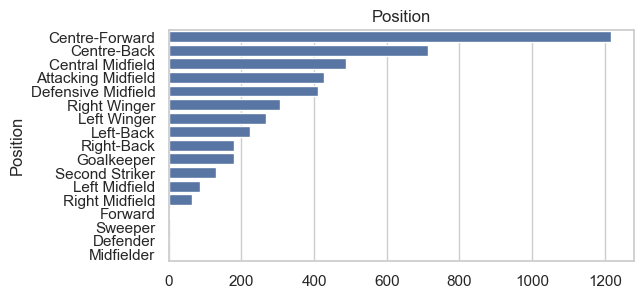


---

Column: Age
 - dtype: int64
 - missing: 0 (0.00%)
 - unique (non-null): 22
count    4700.000000
mean       24.338723
std         3.230809
min         0.000000
25%        22.000000
50%        24.000000
75%        27.000000
max        35.000000
Name: Age, dtype: float64


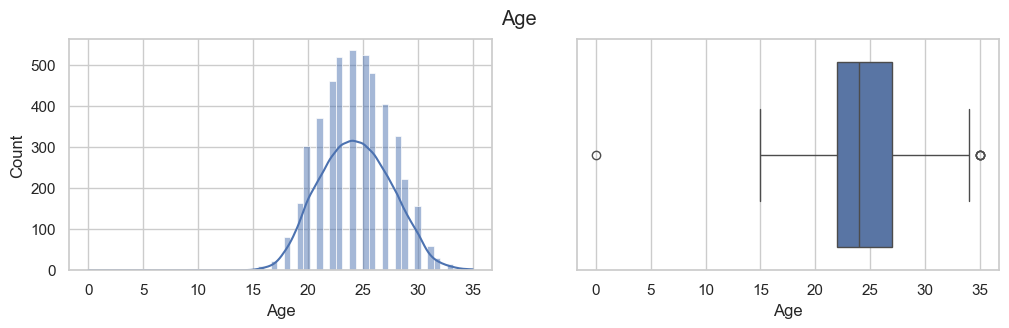


---

Column: Team_from
 - dtype: object
 - missing: 0 (0.00%)
 - unique (non-null): 570


Team_from
Inter              68
Spurs              63
Juventus           59
Chelsea            57
FC Porto           56
Liverpool          56
Real Madrid        53
Benfica            52
Atlético Madrid    52
Udinese Calcio     51
Monaco             47
Genoa              46
Parma              46
AC Milan           44
AS Roma            43
Man Utd            43
Man City           41
Olympique Lyon     40
Newcastle          40
Arsenal            40
Name: count, dtype: int64

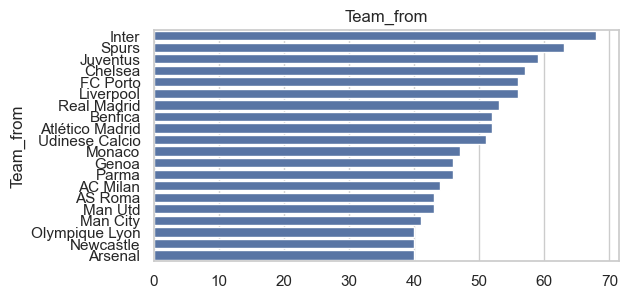


---

Column: League_from
 - dtype: object
 - missing: 0 (0.00%)
 - unique (non-null): 118


League_from
Premier League        608
Serie A               602
Ligue 1               428
LaLiga                418
1.Bundesliga          265
Série A               199
Championship          197
Eredivisie            190
Liga NOS              178
Premier Liga          169
Super League          108
Serie B               100
Süper Lig             100
Jupiler Pro League     91
 Brazil                89
Torneo Final           84
 Argentina             66
LaLiga2                59
First Division         58
Ligue 2                47
Name: count, dtype: int64

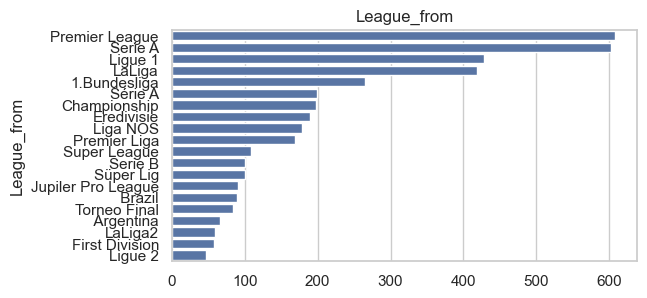


---

Column: Team_to
 - dtype: object
 - missing: 0 (0.00%)
 - unique (non-null): 325


Team_to
Inter              97
Chelsea            96
Man City           94
Spurs              93
Juventus           87
Liverpool          85
AS Roma            77
Real Madrid        75
FC Barcelona       70
Atlético Madrid    69
AC Milan           68
Paris SG           66
Man Utd            65
Everton            63
Monaco             61
Newcastle          61
Arsenal            61
Marseille          60
FC Porto           60
SSC Napoli         58
Name: count, dtype: int64

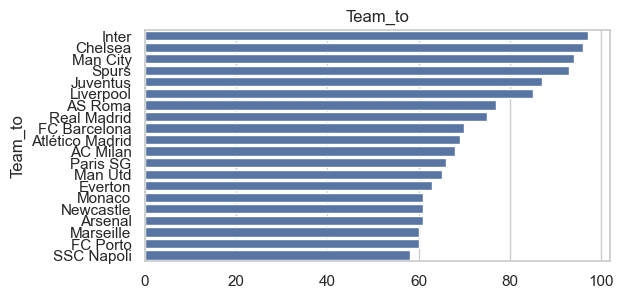


---



In [7]:
# Profile each column (show first 6 to avoid too long output)
for i, col in enumerate(transfers.columns):
    if i >= 6:
        break
    profile_column(transfers, col)
    print('\n---\n')
# If you want to profile all columns uncomment below (may be long)
# for col in transfers.columns:
#     profile_column(transfers, col)
#     print('\n---\n')

### Numeric correlation matrix (transfers)
We compute Pearson correlations for numeric features and visualize a heatmap.

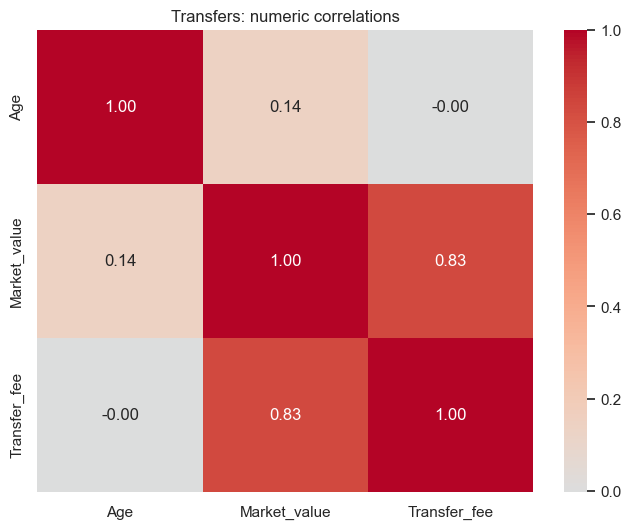

In [8]:
num_cols = transfers.select_dtypes(include=[np.number]).columns.tolist()
corr = transfers[num_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Transfers: numeric correlations')
plt.show()

## Additional profiling: missingness map and duplicates (transfers)

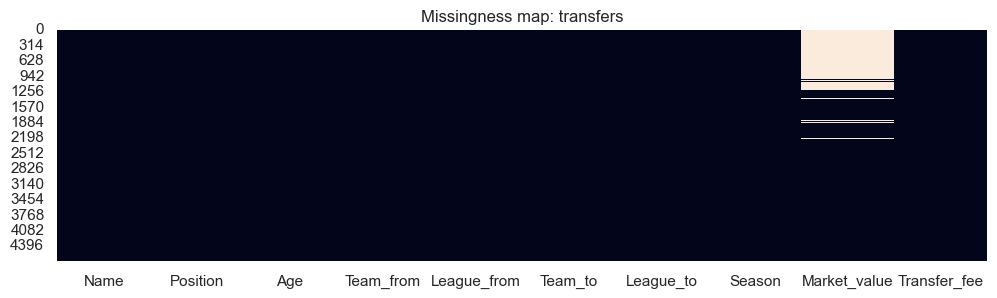

Duplicate rows: 0


In [9]:
plt.figure(figsize=(12,3))
sns.heatmap(transfers.isna(), cbar=False)
plt.title('Missingness map: transfers')
plt.show()
print('Duplicate rows:', transfers.duplicated().sum())

## Profile: ratings dataset (selected features)
We focus on: `short_name`, `age`, `club`, `overall`, `potential`, `season`, `nationality`, `value_eur`, `position` (split to multiple), `league` (infer if possible).

In [10]:
ratings.head()

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,overall,potential,value_eur,wage_eur,player_positions,preferred_foot,international_reputation,weak_foot,skill_moves,work_rate,body_type,real_face,release_clause_eur,player_tags,team_position,team_jersey_number,loaned_from,joined,contract_valid_until,nation_position,nation_jersey_number,pace,shooting,passing,dribbling,defending,physic,gk_diving,gk_handling,gk_kicking,gk_reflexes,gk_speed,gk_positioning,player_traits,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,ls,st,rs,lw,lf,cf,rf,rw,lam,cam,ram,lm,lcm,cm,rcm,rm,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,27,1987-06-24,169,67,Argentina,FC Barcelona,93,95,0,0,CF,Left,5,3,4,Medium/Low,Normal,Yes,NaN,"#Speedster, #Dribbler, #FK Specialist, #Acroba...",CF,10.0,NaN,2004-07-01,2018.0,CF,10.0,93.0,89.0,86.0,96.0,27.0,63.0,NaN,NaN,NaN,NaN,NaN,NaN,"Finesse Shot, Speed Dribbler (CPU AI Only), On...",84,94-3,71,89,85-5,96-1,89+2,90+4,76,96,96,90+2,94,94-2,95,80-1,73,77-1,60,88,48,22,92-1,90,76,NaN,25,21,20,6,11,15,14,8,89+3,89+3,89+3,92+3,90+3,90+3,90+3,92+3,92+3,92+3,92+3,90+3,79+3,79+3,79+3,90+3,62+3,62+3,62+3,62+3,62+3,54+3,45+3,45+3,45+3,54+3
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,29,1985-02-05,185,80,Portugal,Real Madrid,92,92,0,0,"LW, LM",Right,5,4,5,High/Low,Normal,Yes,NaN,"#Speedster, #Dribbler, #Distance Shooter, #Acr...",LW,7.0,NaN,2009-07-01,2018.0,LW,7.0,93.0,93.0,81.0,91.0,32.0,79.0,NaN,NaN,NaN,NaN,NaN,NaN,"Power Free-Kick, Flair, Long Shot Taker (CPU A...",83,95+3,86,82,87+2,93+3,88,79,72,92-3,91,94,93,90,63-12,94,94,89,79,93,63,24,91+2,81,85,NaN,22,31,23,7,11,15,14,11,91+3,91+3,91+3,89+3,91+3,91+3,91+3,89+3,89+3,89+3,89+3,87+3,77+3,77+3,77+3,87+3,63+3,63+3,63+3,63+3,63+3,57+3,52+3,52+3,52+3,57+3
2,9014,https://sofifa.com/player/9014/arjen-robben/15...,A. Robben,Arjen Robben,30,1984-01-23,180,80,Netherlands,FC Bayern München,90,90,0,0,"RM, LM, RW",Left,5,2,4,High/Low,Normal,Yes,NaN,"#Speedster, #Dribbler, #Distance Shooter, #Acr...",SUB,10.0,NaN,2009-08-28,2017.0,RS,11.0,93.0,86.0,83.0,92.0,32.0,64.0,NaN,NaN,NaN,NaN,NaN,NaN,"Diver, Injury Prone, Avoids Using Weaker Foot,...",80,85+2,50,86+2,86+2,93,85,83-1,76+3,90+1,93,93+2,93+1,89+2,91,86,61,78+11,65,90+1,47+9,39+1,89+2,84+2,80+1,NaN,29,26+2,26+1,10,8,11,5,15,84+3,84+3,84+3,88+3,87+3,87+3,87+3,88+3,88+3,88+3,88+3,87+3,78+3,78+3,78+3,87+3,64+3,64+3,64+3,64+3,64+3,55+3,46+3,46+3,46+3,55+3
3,41236,https://sofifa.com/player/41236/zlatan-ibrahim...,Z. Ibrahimović,Zlatan Ibrahimović,32,1981-10-03,195,95,Sweden,Paris Saint-Germain,90,90,0,0,ST,Right,5,4,4,Medium/Low,Normal,Yes,NaN,"#Poacher, #Aerial Threat, #Distance Shooter, #...",ST,10.0,NaN,2012-07-01,2016.0,ST,10.0,76.0,91.0,81.0,86.0,34.0,86.0,NaN,NaN,NaN,NaN,NaN,NaN,"Power Free-Kick, Leadership, Flair, Long Shot ...",76,91,76,84-2,92+3,88,80,80,76+4,90,74+2,77-1,86,85,41,93,72,78,93,88,84,20,86,83-1,91,NaN,25,41-8,27,13,15,10,9,12,87+3,87+3,87+3,84+3,86+3,86+3,86+3,84+3,86+3,86+3,86+3,83+3,76+3,76+3,76+3,83+3,61+3,65+3,65+3,65+3,61+3,56+3,55+3,55+3,55+3,56+3
4,167495,https://sofifa.com/player/167495/manuel-neuer/...,M. Neuer,Manuel Neuer,28,1986-03-27,193,92,Germany,FC Bayern München,90,90,0,0,GK,Right,5,4,1,Medium/Medi

In [11]:
# Show info for selected features (if they exist)
sel = ['short_name','age','club','overall','potential','season','nationality','value_eur','position','league']
sel_existing = [c for c in sel if c in ratings.columns]
sel_existing, 'missing from ratings:' , [c for c in sel if c not in ratings.columns]

(['short_name',
  'age',
  'club',
  'overall',
  'potential',
  'nationality',
  'value_eur'],
 'missing from ratings:',
 ['season', 'position', 'league'])

In [12]:
# Data types & missingness for selected features
ratings_info = pd.DataFrame({
    'dtype': ratings.dtypes.astype(str),
    'n_missing': ratings.isna().sum(),
    'pct_missing': 100 * ratings.isna().mean(),
    'n_unique': ratings.nunique(dropna=True)
})
ratings_info.loc[sel_existing].sort_values('pct_missing', ascending=False)

,dtype,n_missing,pct_missing,n_unique
short_name,object,0,0.0,14555
age,int64,0,0.0,29
club,object,0,0.0,596
overall,int64,0,0.0,53
potential,int64,0,0.0,49
nationality,object,0,0.0,148
value_eur,int64,0,0.0,1


### Profile numeric distributions for `age`, `overall`, `potential`, `value_eur` (when present)

In [13]:
ratings['value_eur'].value_counts()

value_eur
0    15465
Name: count, dtype: int64


== age ==
Column: age
 - dtype: int64
 - missing: 0 (0.00%)
 - unique (non-null): 29
count    15465.000000
mean        24.763272
std          4.624565
min         16.000000
25%         21.000000
50%         24.000000
75%         28.000000
max         44.000000
Name: age, dtype: float64


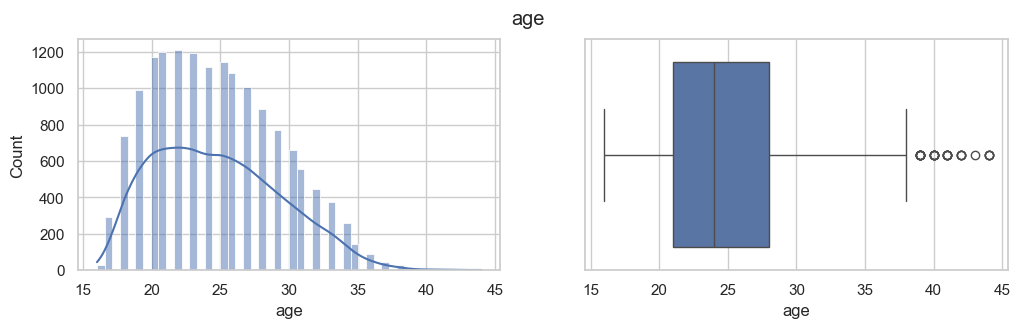


== overall ==
Column: overall
 - dtype: int64
 - missing: 0 (0.00%)
 - unique (non-null): 53
count    15465.000000
mean        63.948594
std          7.208610
min         40.000000
25%         59.000000
50%         64.000000
75%         69.000000
max         93.000000
Name: overall, dtype: float64


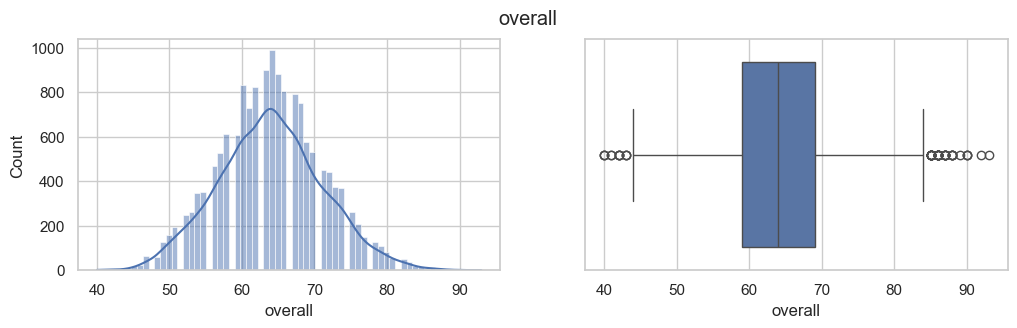


== potential ==
Column: potential
 - dtype: int64
 - missing: 0 (0.00%)
 - unique (non-null): 49
count    15465.000000
mean        68.483091
std          6.611708
min         40.000000
25%         64.000000
50%         68.000000
75%         73.000000
max         95.000000
Name: potential, dtype: float64


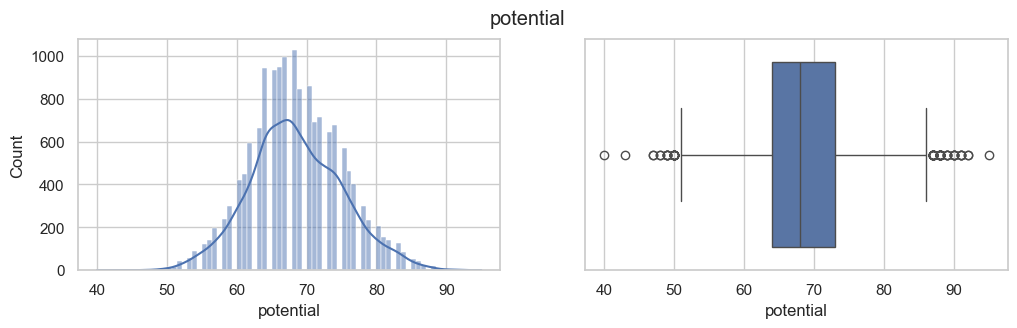


== value_eur ==
Column: value_eur
 - dtype: int64
 - missing: 0 (0.00%)
 - unique (non-null): 1
count    15465.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: value_eur, dtype: float64


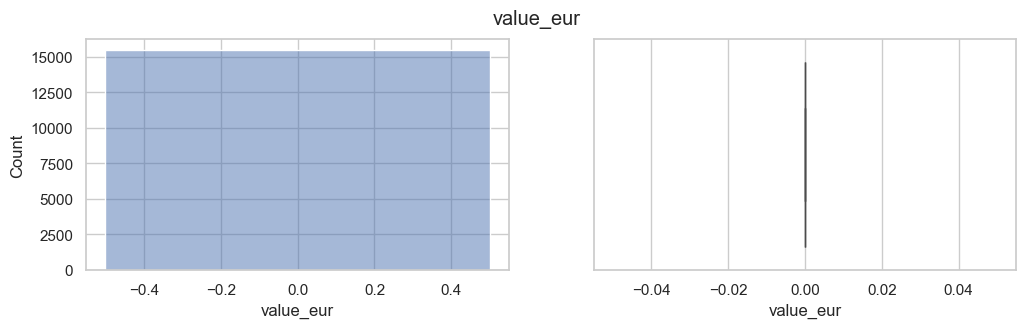

In [14]:
for col in ['age','overall','potential','value_eur']:
    if col in ratings.columns:
        print('\n==', col, '==')
        profile_column(ratings, col)

### Position feature engineering
If `position` is a delimited string of multiple roles, we expand into indicator columns for the common positions.

In [15]:
if 'position' in ratings.columns:
    # Assume positions are separated by '/' or ',' or ';' or '|'
    pos_series = ratings['position'].fillna('')
    split_pos = pos_series.str.replace(r'\s*,\s*', '/', regex=True)
    split_pos = split_pos.str.replace(r'\s*;\s*', '/', regex=True)
    split_pos = split_pos.str.replace(r'\s*\|\s*', '/', regex=True)
    positions = set()
    for s in split_pos.unique():
        if s:
            for p in str(s).split('/'):
                positions.add(p.strip())
    positions = sorted([p for p in positions if p])
    print('Detected positions (sample):', positions[:30])
    # create indicators for top positions
    top_positions = positions[:20]  # limit to first 20 unique tokens
    for p in top_positions:
        ratings[f'pos_{p}'] = split_pos.str.contains(rf'\b{re.escape(p)}\b', regex=True)
    print('Created indicator columns for top positions')
else:
    print('No position column found')

No position column found


### League inference (attempt)
If `league` is not present, try to infer from `transfers` by mapping club -> league where possible.

In [16]:
if 'league' not in ratings.columns:
    # Try mapping from transfers if transfers has a league-like column and club field
    possible_club_cols = [c for c in transfers.columns if 'club' in c.lower() or 'team' in c.lower()]
    possible_league_cols = [c for c in transfers.columns if 'league' in c.lower() or 'division' in c.lower()]
    print('transfers club-like cols:', possible_club_cols)
    print('transfers league-like cols:', possible_league_cols)
    if possible_club_cols and possible_league_cols:
        club_col = possible_club_cols[0]
        league_col = possible_league_cols[0]
        mapping = transfers[[club_col, league_col]].dropna().drop_duplicates().set_index(club_col)[league_col].to_dict()
        # apply mapping where club names match exactly
        ratings['inferred_league'] = ratings['club'].map(mapping)
        n_inferred = ratings['inferred_league'].notna().sum()
        print('Inferred league for', n_inferred, 'rows')
    else:
        print('Could not find club/league columns in transfers to infer league')
else:
    print('ratings already contains league column')

transfers club-like cols: ['Team_from', 'Team_to']
transfers league-like cols: ['League_from', 'League_to']
Inferred league for 4132 rows


In [17]:
# Inspect inferred_league results
if 'inferred_league' in ratings.columns:
    n_inferred = ratings['inferred_league'].notna().sum()
    print('Inferred leagues for', n_inferred, 'rows (of', len(ratings), ')')
    display(ratings['inferred_league'].value_counts().head(20))
    display(ratings[['club','inferred_league']].dropna().drop_duplicates().head(30))
else:
    print('No inferred_league column found')

Inferred leagues for 4132 rows (of 15465 )


inferred_league
LaLiga                465
Championship          384
Serie B               329
Premier League        291
Serie A               274
2.Bundesliga          206
Eredivisie            175
Primera División      173
LaLiga2               172
Jupiler Pro League    135
1.Bundesliga          121
Super League          105
Eliteserien            98
Premier Liga           84
Ligue 1                84
Allsvenskan            77
League One             61
Ligue 2                61
Liga MX Clausura       58
Süper Lig              58
Name: count, dtype: int64

,club,inferred_league
0,FC Barcelona,LaLiga
1,Real Madrid,LaLiga
6,Chelsea,Premier League
26,Arsenal,Premier League
37,Juventus,Serie B
45,Atlético Madrid,LaLiga
60,FC Schalke 04,1.Bundesliga
67,Fiorentina,Serie A
68,Liverpool,Premier League
76,Lazio,Serie A


### Pairwise correlations (ratings numeric features)
Compute correlations for numeric features such as `age`, `overall`, `potential`, `value_eur`.

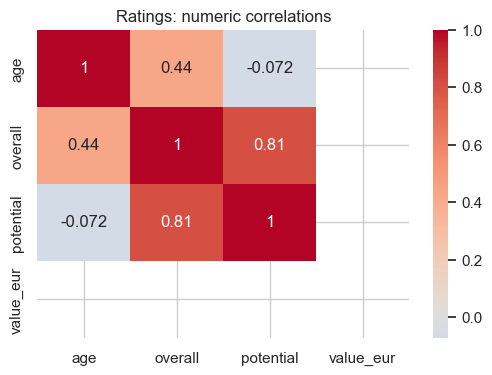

In [18]:
num_cols_r = [c for c in ['age','overall','potential','value_eur'] if c in ratings.columns]
if num_cols_r:
    corr_r = ratings[num_cols_r].corr()
    plt.figure(figsize=(6,4))
    sns.heatmap(corr_r, annot=True, cmap='coolwarm', center=0)
    plt.title('Ratings: numeric correlations')
    plt.show()
else:
    print('No target numeric columns present')

In [19]:
# Summarize findings succinctly
print('Transfers columns summary:')
display(transfers_info.head(50))
print('\nRatings selected features summary:')
display(ratings_info.loc[sel_existing])

Transfers columns summary:


,dtype,n_missing,pct_missing,n_unique
Name,object,0,0.000000,3104
Position,object,0,0.000000,17
Age,int64,0,0.000000,22
Team_from,object,0,0.000000,570
League_from,object,0,0.000000,118
Team_to,object,0,0.000000,325
League_to,object,0,0.000000,65
Season,object,0,0.000000,19
Market_value,float64,1260,26.808511,180
Transfer_fee,int64,0,0.000000,507



Ratings selected features summary:


,dtype,n_missing,pct_missing,n_unique
short_name,object,0,0.0,14555
age,int64,0,0.0,29
club,object,0,0.0,596
overall,int64,0,0.0,53
potential,int64,0,0.0,49
nationality,object,0,0.0,148
value_eur,int64,0,0.0,1


## Next steps / notes
- Run the full `profile_column` loop over all transfers columns (commented) if you want every column expanded.
- Consider normalizing `value_eur` (large skew) with log1p for modeling.
- For `position`, consider multi-hot encoding for machine learning.
- For `league`, obtaining a reliable external mapping (club -> league) improves analyses across seasons.

## Enhanced correlations — Spearman & log-scale

Pearson is sensitive to outliers and right-skewed distributions. Transfer fees and market values are heavily skewed, so we add:
- **Spearman** rank correlation — robust to skew and outliers
- **Pearson on log-transformed** values — removes scale distortion from large fees

Comparing all three gives a fuller picture of the true relationships.

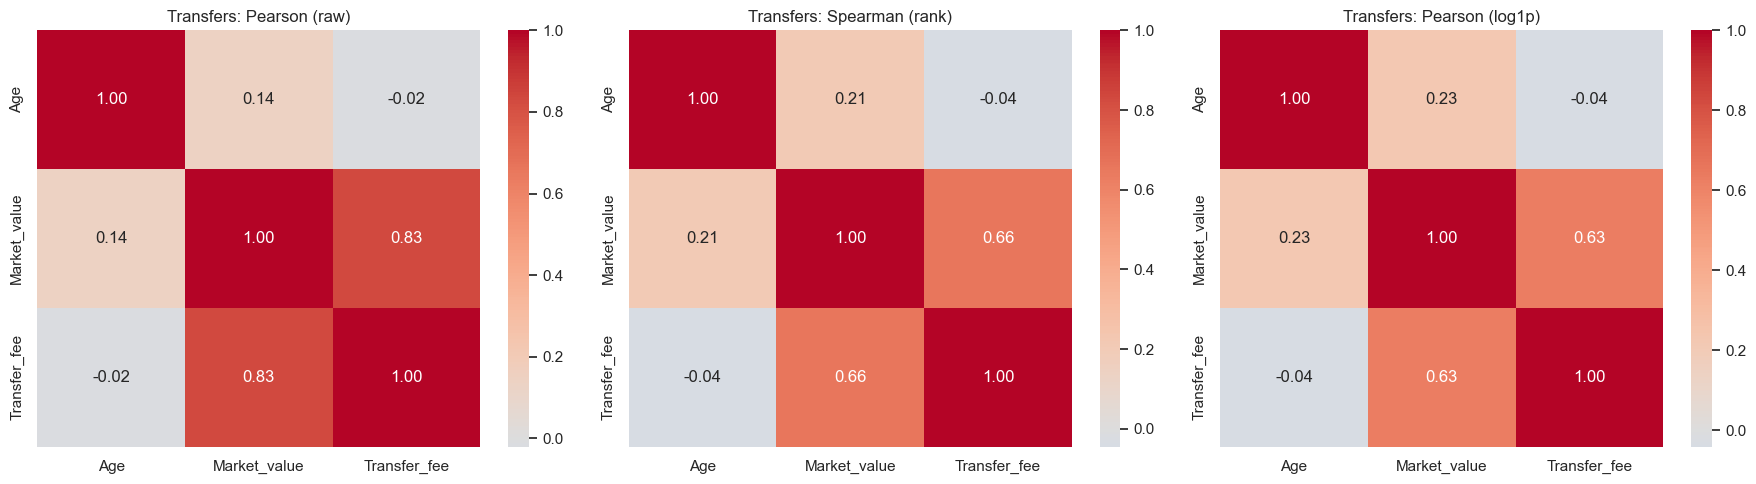

In [20]:
# Transfers: Pearson (raw), Spearman (rank), Pearson on log1p-transformed
num_cols_t = transfers.select_dtypes(include=[np.number]).columns.tolist()
transfers_num = transfers[num_cols_t].dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(transfers_num.corr(method='pearson'), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=axes[0])
axes[0].set_title('Transfers: Pearson (raw)')

sns.heatmap(transfers_num.corr(method='spearman'), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Transfers: Spearman (rank)')

transfers_log = np.log1p(transfers_num.clip(lower=0))
sns.heatmap(transfers_log.corr(method='pearson'), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=axes[2])
axes[2].set_title('Transfers: Pearson (log1p)')

plt.tight_layout()
plt.show()

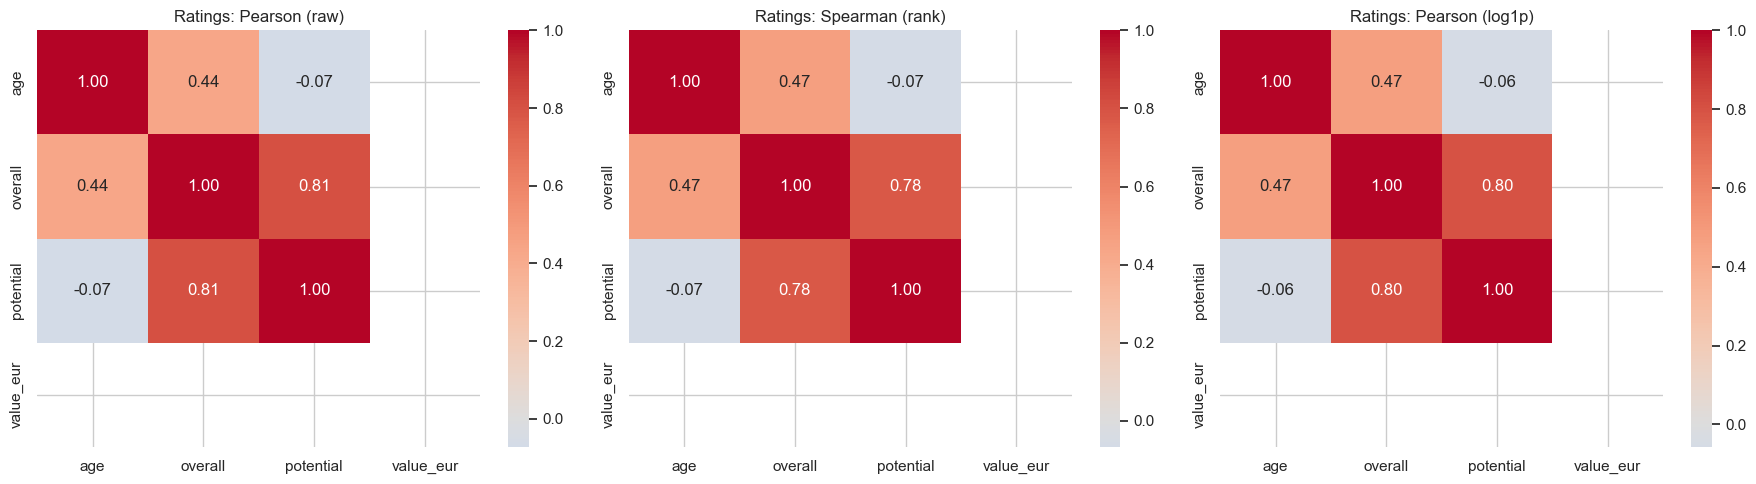

In [21]:
# Ratings: Pearson (raw), Spearman (rank), Pearson on log1p-transformed
num_cols_r = [c for c in ['age', 'overall', 'potential', 'value_eur'] if c in ratings.columns]
ratings_num = ratings[num_cols_r].dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(ratings_num.corr(method='pearson'), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=axes[0])
axes[0].set_title('Ratings: Pearson (raw)')

sns.heatmap(ratings_num.corr(method='spearman'), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Ratings: Spearman (rank)')

ratings_log = np.log1p(ratings_num.clip(lower=0))
sns.heatmap(ratings_log.corr(method='pearson'), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=axes[2])
axes[2].set_title('Ratings: Pearson (log1p)')

plt.tight_layout()
plt.show()

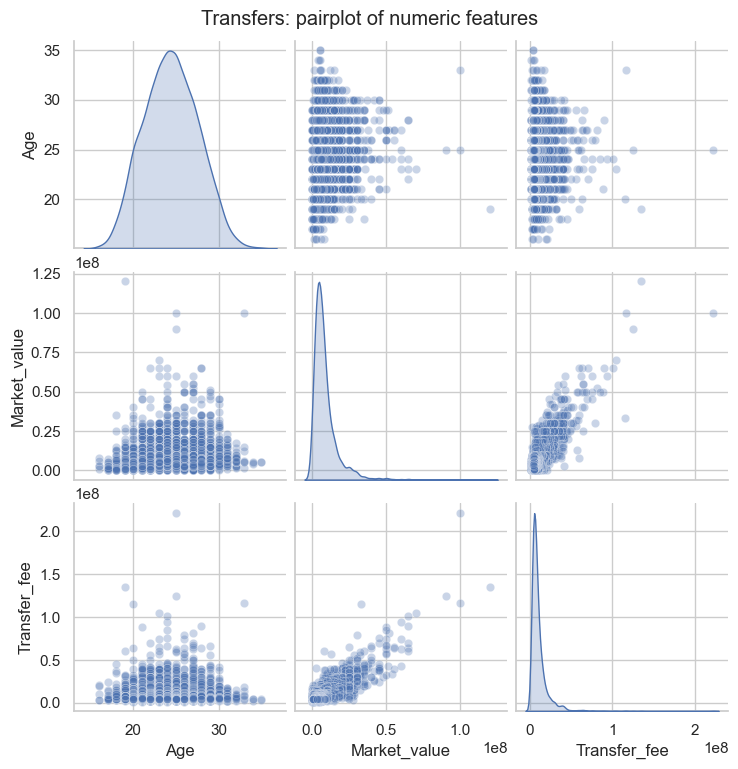

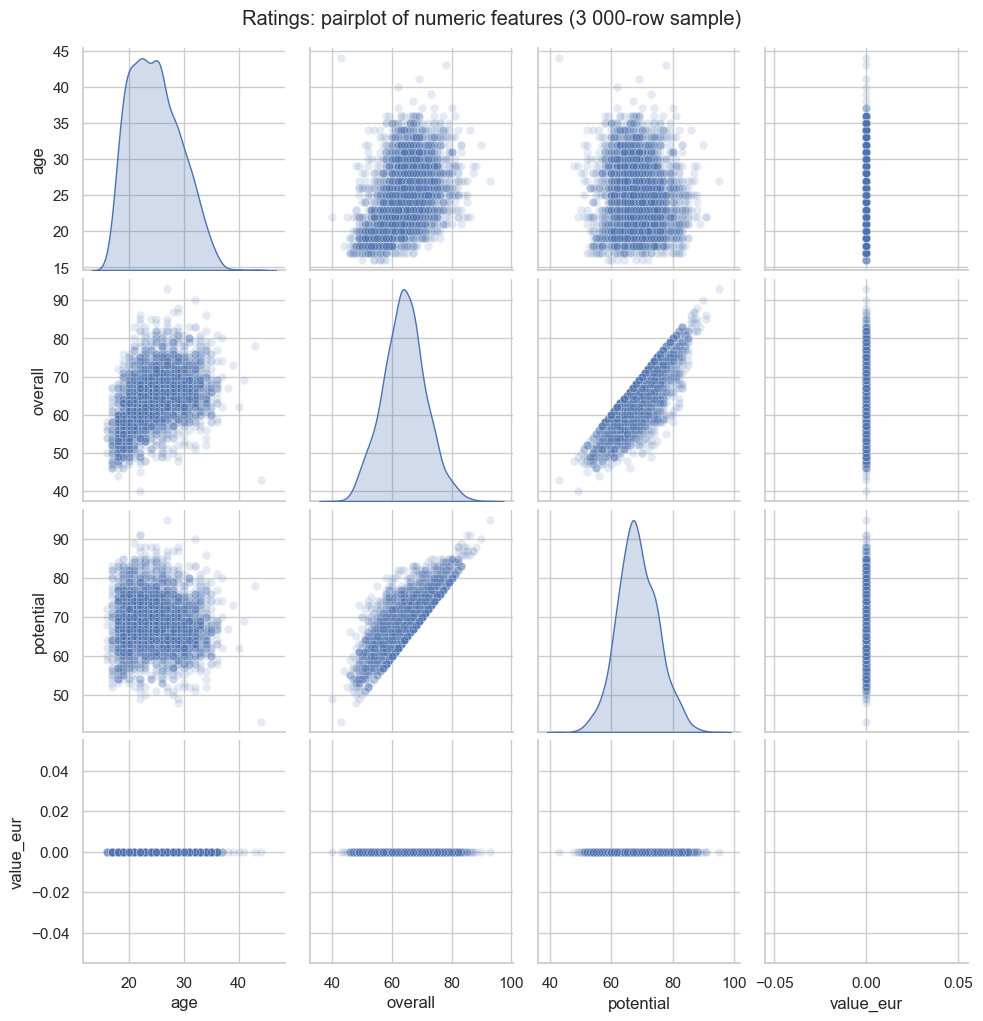

In [22]:
# Pairplots — show scatter distributions between all numeric feature pairs

# Transfers
transfers_pair = transfers[['Age', 'Market_value', 'Transfer_fee']].dropna()
g = sns.pairplot(transfers_pair, diag_kind='kde', plot_kws={'alpha': 0.3})
g.fig.suptitle('Transfers: pairplot of numeric features', y=1.02)
plt.show()

# Ratings (sample for speed)
ratings_pair = (ratings[['age', 'overall', 'potential', 'value_eur']]
                .dropna()
                .sample(min(3000, len(ratings)), random_state=42))
g2 = sns.pairplot(ratings_pair, diag_kind='kde', plot_kws={'alpha': 0.15})
g2.fig.suptitle('Ratings: pairplot of numeric features (3 000-row sample)', y=1.02)
plt.show()

## Cross-dataset correlations (merged transfers × FIFA ratings)

Join transfers (seasons 2015–2018) with FIFA ratings on **last name + season + club** to produce a merged dataset. This lets us examine how FIFA ability ratings (`overall`, `potential`) correlate with actual `Transfer_fee` alongside `Age` and `Market_value`.

> **Merge note:** We use a simple last-name + season + club match (no fuzzy matching), which is fast and reproducible. Expect ~400–700 matched rows — sufficient for correlation analysis.

In [23]:
# ── Load FIFA seasons 2015-2018 ──────────────────────────────────────────────
season_files = {
    'players_15.csv': 2015, 'players_16.csv': 2016,
    'players_17.csv': 2017, 'players_18.csv': 2018,
}

frames = []
with zipfile.ZipFile(ratings_zip) as z:
    available = z.namelist()
    for fname, yr in season_files.items():
        if fname in available:
            with z.open(fname) as f:
                df = pd.read_csv(f, low_memory=False)
            nat_col = next(
                (c for c in ['nationality_name', 'nationality'] if c in df.columns), None
            )
            keep = ['short_name', 'club', 'overall', 'potential']
            if nat_col:
                keep.append(nat_col)
            df = df[keep].copy()
            df['Season_yr'] = yr
            if nat_col and nat_col != 'Nationality':
                df = df.rename(columns={nat_col: 'Nationality'})
            frames.append(df)

fifas = pd.concat(frames, ignore_index=True)
fifas['Lastname'] = fifas['short_name'].str.split().str[-1]

for col in ['Lastname', 'club']:
    fifas[col] = (fifas[col]
                  .str.normalize('NFKD')
                  .str.encode('ascii', errors='ignore')
                  .str.decode('utf-8'))

# ── Prepare transfers 2015-2018 ───────────────────────────────────────────────
transfers_t = transfers.copy()
transfers_t['Season_yr'] = transfers_t['Season'].str[:4].astype(int, errors='ignore')
transfers_t = transfers_t[transfers_t['Season_yr'].between(2015, 2018)].copy()
transfers_t['Lastname'] = transfers_t['Name'].str.split().str[-1]
transfers_t['Transfer_fee_mln'] = transfers_t['Transfer_fee'] / 1e6
transfers_t['Market_value_mln'] = transfers_t['Market_value'] / 1e6

for col in ['Lastname', 'Team_from', 'Team_to']:
    transfers_t[col] = (transfers_t[col]
                        .str.normalize('NFKD')
                        .str.encode('ascii', errors='ignore')
                        .str.decode('utf-8'))

# ── Merge on Lastname + Season_yr + Team_from (primary), Team_to (fallback) ──
merged_primary = transfers_t.merge(
    fifas, how='inner',
    left_on=['Lastname', 'Season_yr', 'Team_from'],
    right_on=['Lastname', 'Season_yr', 'club'],
)
matched_idx = set(merged_primary['Name'].tolist())

unmatched = transfers_t[~transfers_t['Name'].isin(matched_idx)].copy()
merged_fallback = unmatched.merge(
    fifas, how='inner',
    left_on=['Lastname', 'Season_yr', 'Team_to'],
    right_on=['Lastname', 'Season_yr', 'club'],
)

merged_full = (pd.concat([merged_primary, merged_fallback], ignore_index=True)
               .dropna(subset=['overall', 'potential', 'Transfer_fee_mln']))

print(f'Matched rows: {len(merged_full)}')
merged_full[['Name', 'Age', 'Team_from', 'League_to',
             'overall', 'potential', 'Market_value_mln', 'Transfer_fee_mln']].head()

Matched rows: 381


,Name,Age,Team_from,League_to,overall,potential,Market_value_mln,Transfer_fee_mln
0,Kevin De Bruyne,24,VfL Wolfsburg,Premier League,81,86,45.0,76.0
1,Raheem Sterling,20,Liverpool,Premier League,80,86,40.0,63.7
2,Christian Benteke,24,Aston Villa,Premier League,80,85,20.0,46.5
3,Nicolás Otamendi,27,Valencia CF,Premier League,80,84,25.0,44.6
4,Julian Draxler,21,FC Schalke 04,1.Bundesliga,80,85,22.0,43.0


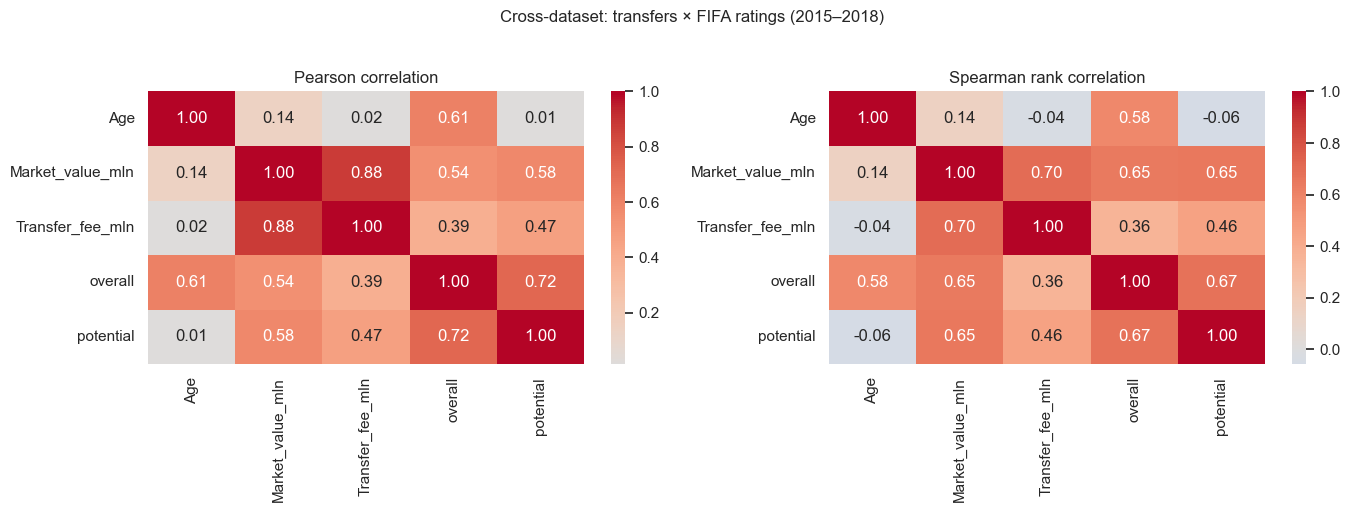

In [24]:
# Cross-dataset correlation matrix: all model-relevant numeric features
feat_cols = ['Age', 'Market_value_mln', 'Transfer_fee_mln', 'overall', 'potential']
feat_df = merged_full[feat_cols].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(feat_df.corr(method='pearson'), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=axes[0])
axes[0].set_title('Pearson correlation')

sns.heatmap(feat_df.corr(method='spearman'), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Spearman rank correlation')

plt.suptitle('Cross-dataset: transfers × FIFA ratings (2015–2018)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

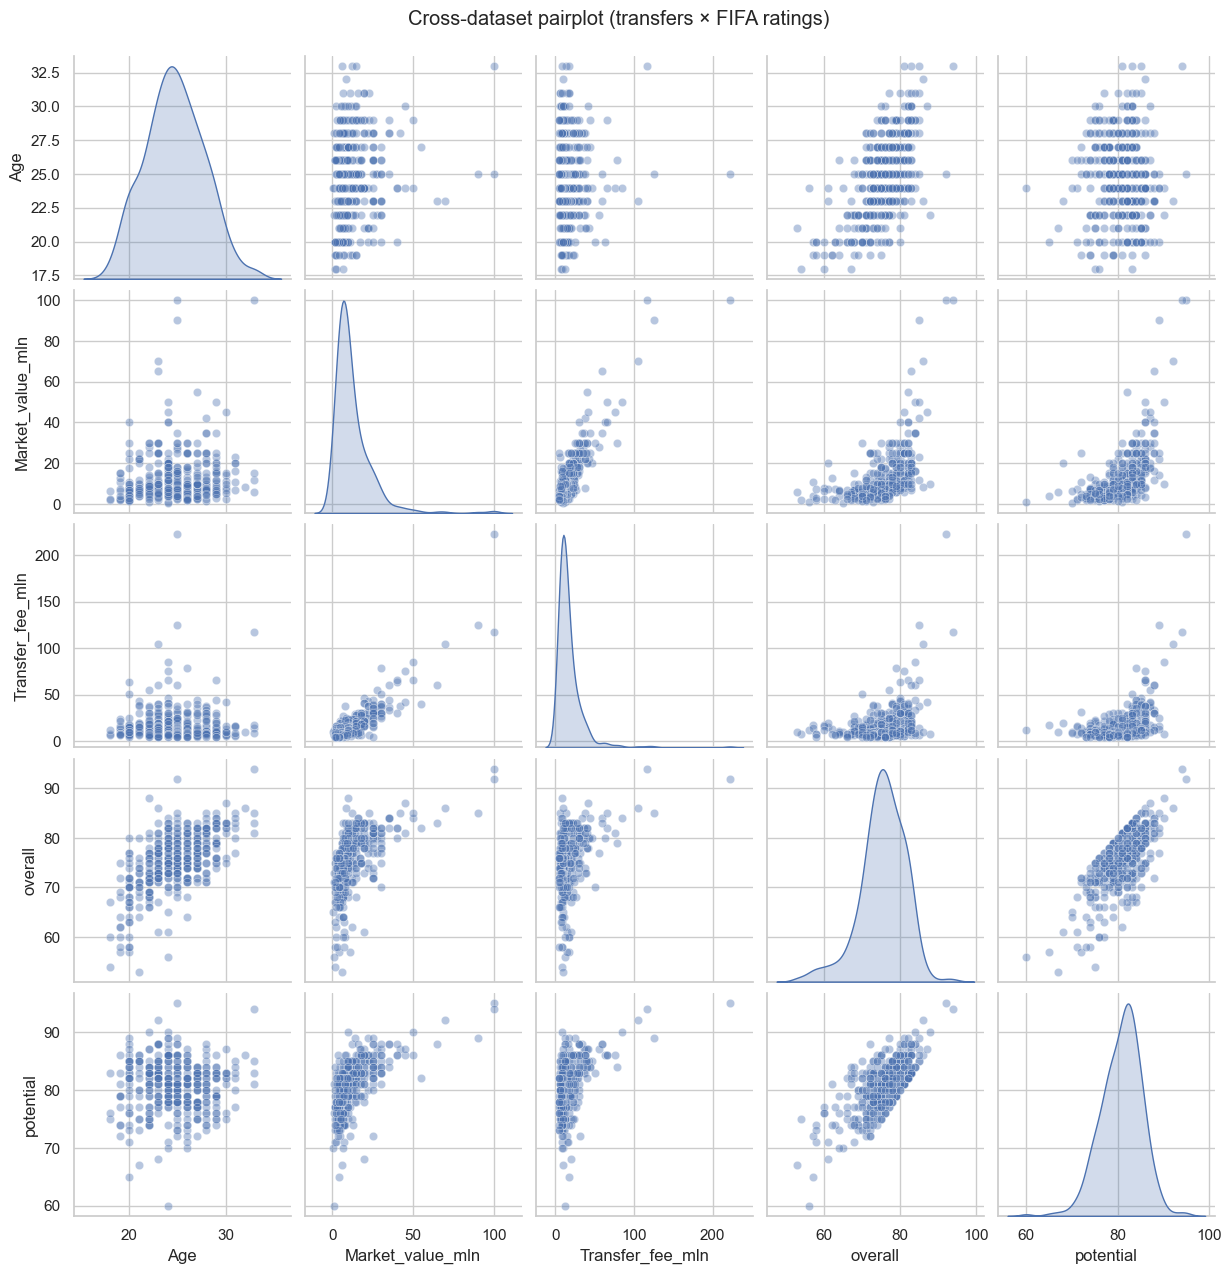

In [25]:
# Pairplot of merged features — reveals non-linear relationships and outliers
g = sns.pairplot(feat_df, diag_kind='kde', plot_kws={'alpha': 0.4})
g.fig.suptitle('Cross-dataset pairplot (transfers × FIFA ratings)', y=1.02)
plt.show()

## Group-level fairness correlations

For the fairness audit the key question is: does the relationship between player **ability** (`overall`) and **Transfer fee** hold equally across all groups?

We compute the **Spearman rank correlation** between `overall` and `Transfer_fee_mln` within each subgroup:
- **Nationality** — are some nationalities systematically under/over-priced for their ability?
- **Destination league** — do fees track ability more closely for some leagues?
- **Position group** — is the ability–fee link consistent across GKs, defenders, midfielders, forwards?

A group with a low or negative Spearman *r* suggests that ability is a weak or perverse predictor of fee for players in that group — a candidate fairness concern.

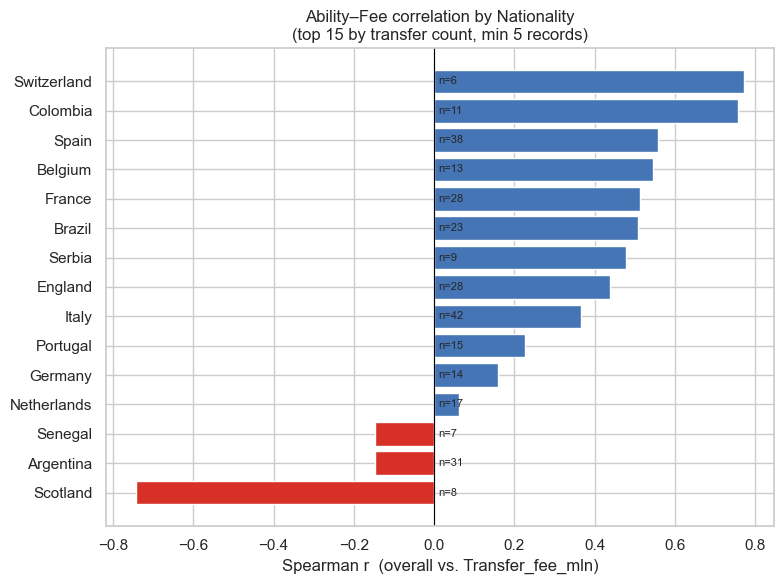

,Nationality,n,spearman_r,p_value
0,Scotland,8,-0.742859,0.034730
1,Argentina,31,-0.148133,0.426451
2,Senegal,7,-0.146795,0.753469
3,Netherlands,17,0.061843,0.813597
4,Germany,14,0.160045,0.584692
5,Portugal,15,0.226415,0.417109
6,Italy,42,0.366833,0.016868
7,England,28,0.439393,0.019312
8,Serbia,9,0.478992,0.192049
9,Brazil,23,0.507069,0.013530


In [26]:
from scipy import stats

# Spearman(overall, Transfer_fee_mln) by nationality — top 15 by transfer count
if 'Nationality' in merged_full.columns:
    nat_counts = merged_full['Nationality'].value_counts()
    top_nats = nat_counts[nat_counts >= 5].index.tolist()[:15]

    nat_corr = []
    for nat in top_nats:
        sub = (merged_full[merged_full['Nationality'] == nat]
               [['overall', 'Transfer_fee_mln']].dropna())
        if len(sub) >= 5:
            r, p = stats.spearmanr(sub['overall'], sub['Transfer_fee_mln'])
            nat_corr.append({'Nationality': nat, 'n': len(sub), 'spearman_r': r, 'p_value': p})

    nat_corr_df = pd.DataFrame(nat_corr).sort_values('spearman_r', ascending=True)

    plt.figure(figsize=(8, 6))
    colors = ['#d73027' if r < 0 else '#4575b4' for r in nat_corr_df['spearman_r']]
    plt.barh(nat_corr_df['Nationality'], nat_corr_df['spearman_r'], color=colors)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.xlabel('Spearman r  (overall vs. Transfer_fee_mln)')
    plt.title('Ability–Fee correlation by Nationality\n(top 15 by transfer count, min 5 records)')
    for i, row in nat_corr_df.reset_index(drop=True).iterrows():
        plt.text(0.01, i, f"n={int(row['n'])}", va='center', fontsize=8)
    plt.tight_layout()
    plt.show()
    display(nat_corr_df.reset_index(drop=True))
else:
    print('Nationality column not available in merged_full.')

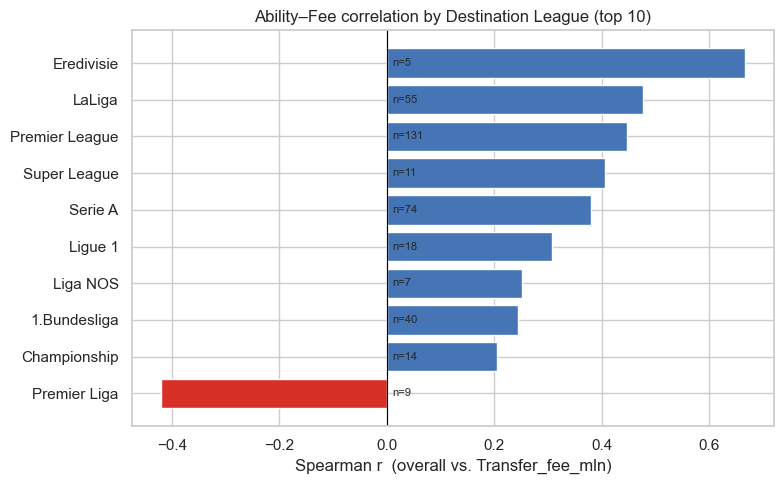

,League_to,n,spearman_r,p_value
0,Premier Liga,9,-0.420636,2.595915e-01
1,Championship,14,0.204908,4.822265e-01
2,1.Bundesliga,40,0.243582,1.298704e-01
3,Liga NOS,7,0.252262,5.852411e-01
4,Ligue 1,18,0.307492,2.145071e-01
5,Serie A,74,0.380837,8.157293e-04
6,Super League,11,0.406397,2.148642e-01
7,Premier League,131,0.447996,8.071625e-08
8,LaLiga,55,0.476718,2.337112e-04
9,Eredivisie,5,0.666886,2.188940e-01


In [27]:
# Spearman(overall, Transfer_fee_mln) by destination league (League_to)
league_counts = merged_full['League_to'].value_counts()
top_leagues = league_counts[league_counts >= 5].index.tolist()[:10]

league_corr = []
for league in top_leagues:
    sub = (merged_full[merged_full['League_to'] == league]
           [['overall', 'Transfer_fee_mln']].dropna())
    if len(sub) >= 5:
        r, p = stats.spearmanr(sub['overall'], sub['Transfer_fee_mln'])
        league_corr.append({'League_to': league, 'n': len(sub), 'spearman_r': r, 'p_value': p})

league_corr_df = pd.DataFrame(league_corr).sort_values('spearman_r', ascending=True)

plt.figure(figsize=(8, 5))
colors = ['#d73027' if r < 0 else '#4575b4' for r in league_corr_df['spearman_r']]
plt.barh(league_corr_df['League_to'], league_corr_df['spearman_r'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Spearman r  (overall vs. Transfer_fee_mln)')
plt.title('Ability–Fee correlation by Destination League (top 10)')
for i, row in league_corr_df.reset_index(drop=True).iterrows():
    plt.text(0.01, i, f"n={int(row['n'])}", va='center', fontsize=8)
plt.tight_layout()
plt.show()
display(league_corr_df.reset_index(drop=True))

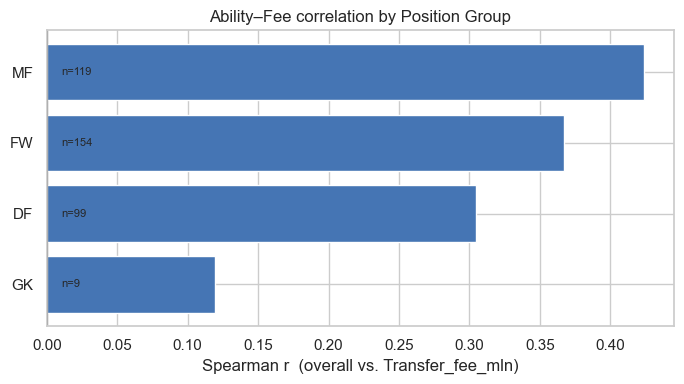

,PositionGroup,n,spearman_r,p_value
0,GK,9,0.119676,0.759090
1,DF,99,0.304845,0.002155
2,FW,154,0.367472,0.000003
3,MF,119,0.424001,0.000002


In [28]:
# Spearman(overall, Transfer_fee_mln) by broad position group
pos_map = {
    r'(?i)goalkeeper': 'GK',
    r'(?i)(centre.back|right.back|left.back|defender|wing.back)': 'DF',
    r'(?i)(midfielder|midfield|defensive mid|central mid|attacking mid)': 'MF',
    r'(?i)(forward|winger|striker|centre.forward)': 'FW',
}

def map_position(pos):
    if pd.isna(pos):
        return 'Other'
    for pattern, group in pos_map.items():
        if re.search(pattern, pos):
            return group
    return 'Other'

merged_full['PositionGroup'] = merged_full['Position'].apply(map_position)

pos_corr = []
for pos in merged_full['PositionGroup'].unique():
    sub = (merged_full[merged_full['PositionGroup'] == pos]
           [['overall', 'Transfer_fee_mln']].dropna())
    if len(sub) >= 5:
        r, p = stats.spearmanr(sub['overall'], sub['Transfer_fee_mln'])
        pos_corr.append({'PositionGroup': pos, 'n': len(sub), 'spearman_r': r, 'p_value': p})

pos_corr_df = pd.DataFrame(pos_corr).sort_values('spearman_r', ascending=True)

plt.figure(figsize=(7, 4))
colors = ['#d73027' if r < 0 else '#4575b4' for r in pos_corr_df['spearman_r']]
plt.barh(pos_corr_df['PositionGroup'], pos_corr_df['spearman_r'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Spearman r  (overall vs. Transfer_fee_mln)')
plt.title('Ability–Fee correlation by Position Group')
for i, row in pos_corr_df.reset_index(drop=True).iterrows():
    plt.text(0.01, i, f"n={int(row['n'])}", va='center', fontsize=8)
plt.tight_layout()
plt.show()
display(pos_corr_df.reset_index(drop=True))